## Import de librerías

In [40]:
# Import de librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import statsmodels.api as sm
import glob
import polars as pl
import timeit
import math


## Import de dataset

In [41]:
# path a los archivos parquet
##files = glob.glob("../dataset/*.parquet")
files = glob.glob("../dataset/04-null-processed/yellow_tripdata_2024-01.parquet")

# leer .parquet files y concatenar en un solo df 
df = pd.concat([pd.read_parquet(f) for f in files], ignore_index=True)

print(len(files), "files merged")
print(df.shape)

# Formato de visualización de floats en pandas
pd.set_option('display.float_format', '{:.2f}'.format)


1 files merged
(2933082, 24)


## Análisis de outliers

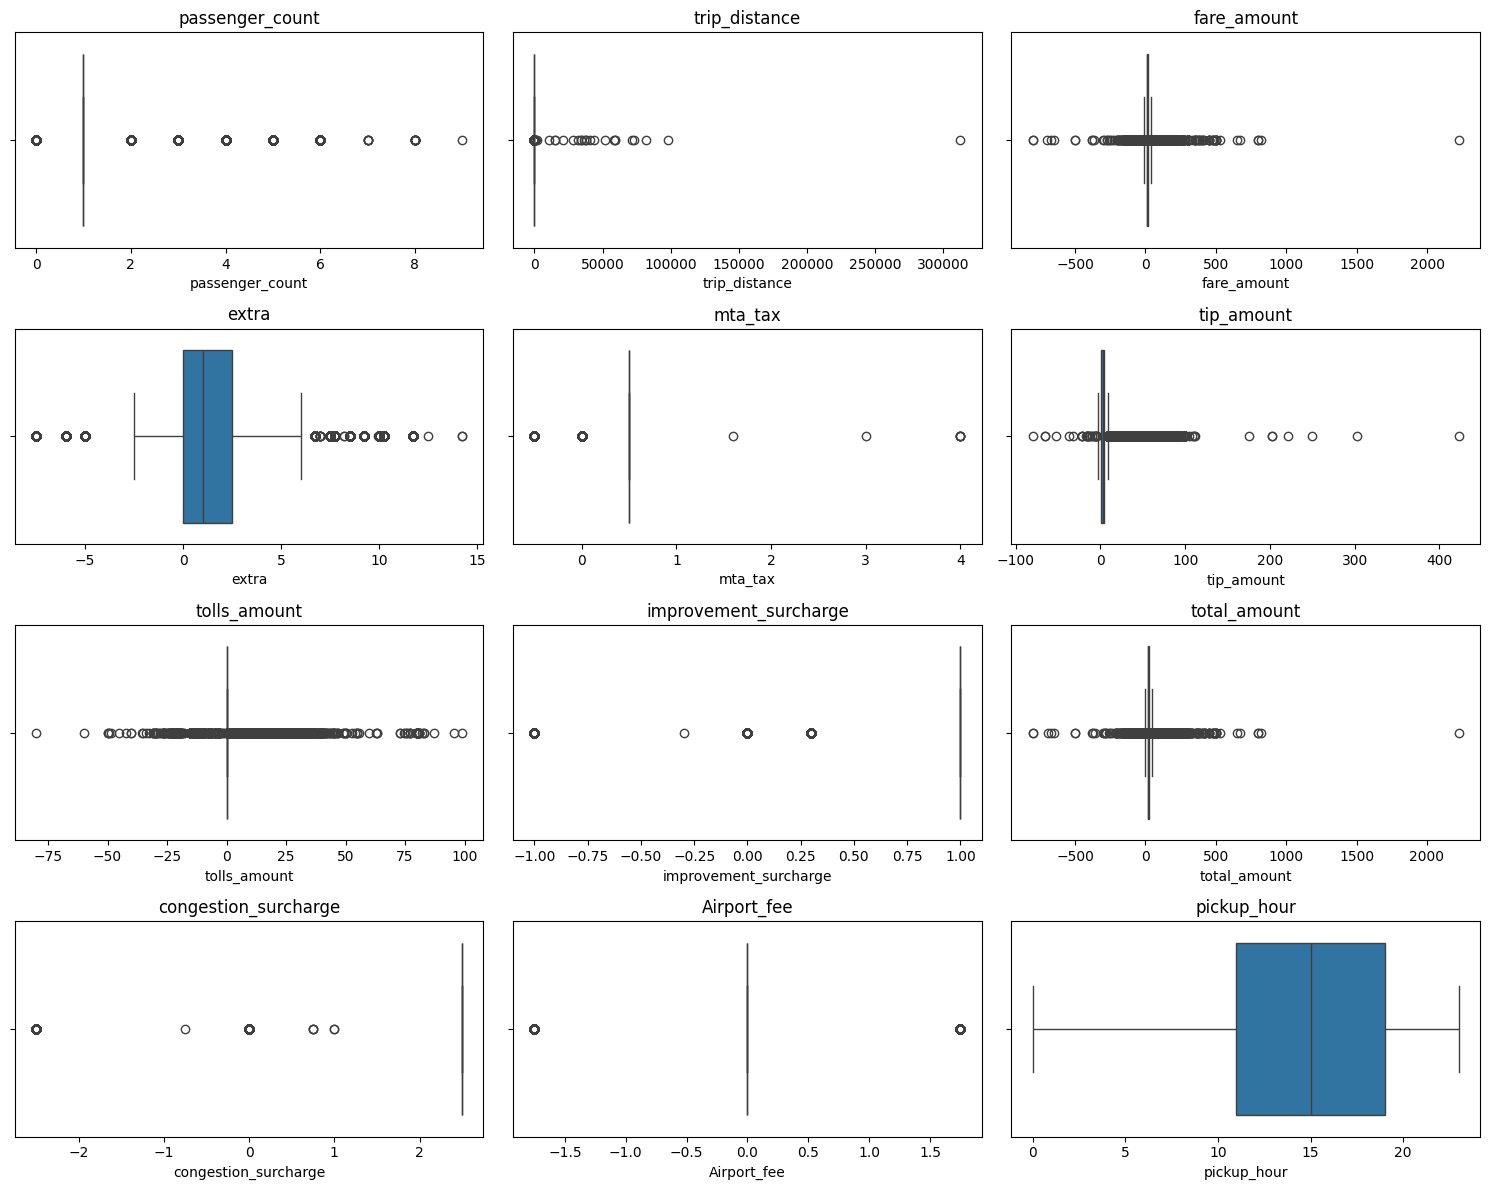

In [42]:

# columnas numéricas
num_cols = df.select_dtypes(include=np.number).columns.tolist()
n = len(num_cols)

# definimos número de filas y columnas del grid
cols = 3   # puedes cambiarlo a 2, 4, etc.
rows = math.ceil(n / cols)

plt.figure(figsize=(cols * 5, rows * 3))

for i, col in enumerate(num_cols, 1):
    plt.subplot(rows, cols, i)
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.tight_layout()

plt.show()

## Ajuste de negativos

In [43]:
# ninguna de las columnas numéricas debería tener valores negativos, pasamos a valor absoluto
for col in num_cols:
    df[col] = df[col].abs()

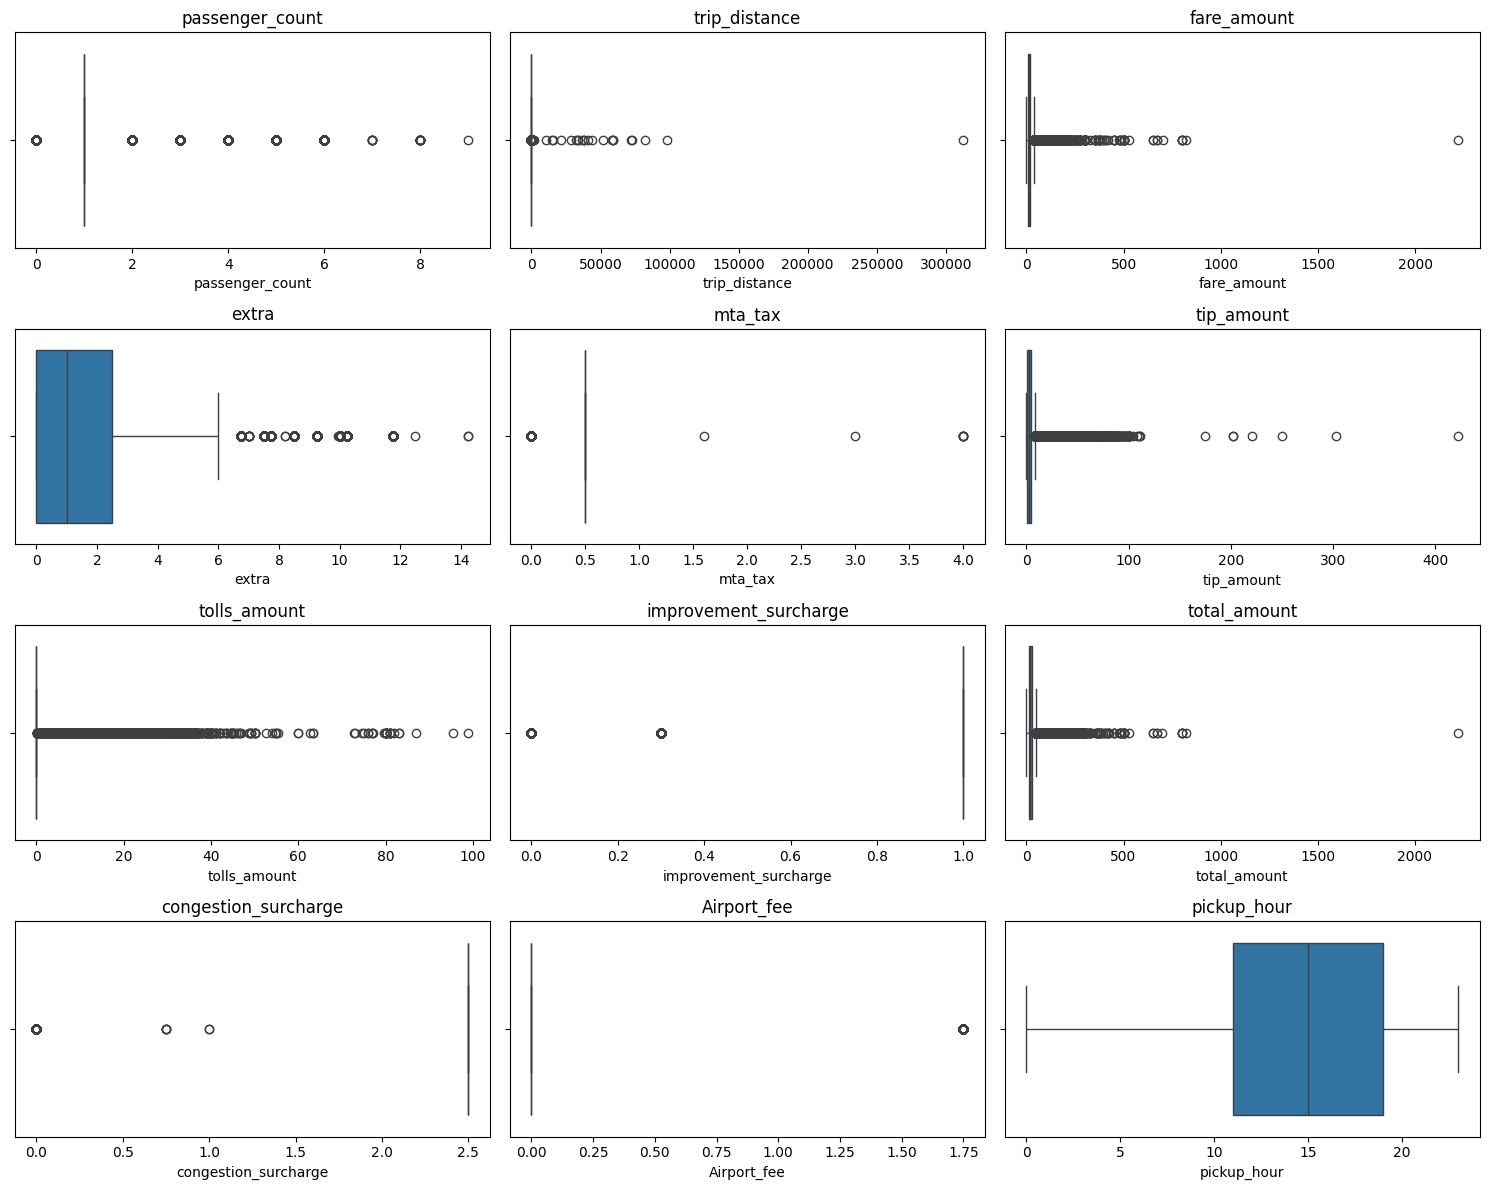

In [44]:

# columnas numéricas
num_cols = df.select_dtypes(include=np.number).columns.tolist()
n = len(num_cols)

# definimos número de filas y columnas del grid
cols = 3   # puedes cambiarlo a 2, 4, etc.
rows = math.ceil(n / cols)

plt.figure(figsize=(cols * 5, rows * 3))

for i, col in enumerate(num_cols, 1):
    plt.subplot(rows, cols, i)
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.tight_layout()

plt.show()

## Seteo de IQR 

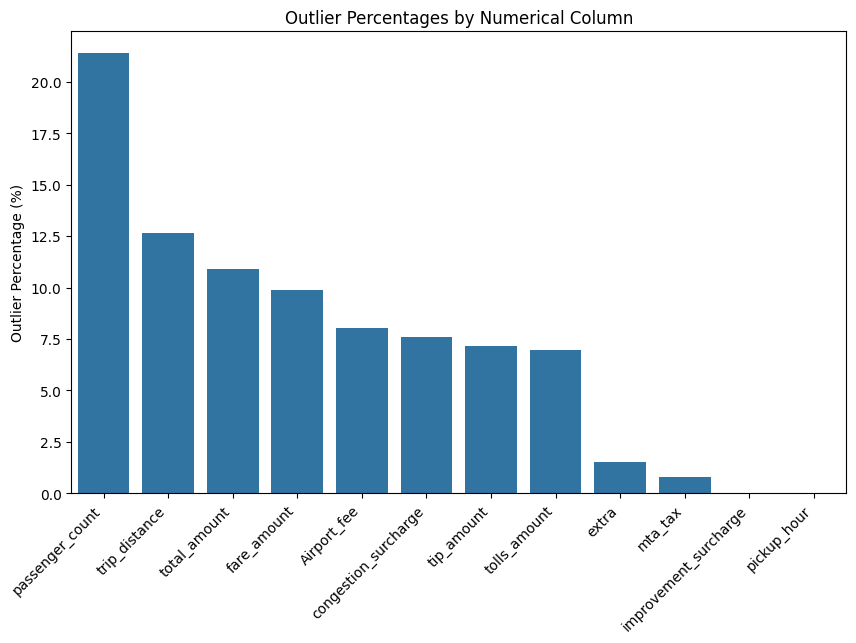

In [45]:
iqr_ranges = {}

for col in num_cols:
    series = df[col].dropna()
    
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    iqr_ranges[col] = {
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "LowerBound": lower,
        "UpperBound": upper
    }

# grafico barras porcentajes de outliers por columna numérica
outlier_percentages = {}
for col in num_cols:
    lower = iqr_ranges[col]["LowerBound"]
    upper = iqr_ranges[col]["UpperBound"]
    
    total_count = len(df)
    outlier_count = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    
    outlier_percentage = (outlier_count / total_count) * 100
    outlier_percentages[col] = outlier_percentage
# gráfico de barras ordenado mayor a menor
outlier_percentages = dict(sorted(outlier_percentages.items(), key=lambda item: item[1], reverse=True))
plt.figure(figsize=(10, 6)) 
sns.barplot(x=list(outlier_percentages.keys()), y=list(outlier_percentages.values()))
plt.xticks(rotation=45, ha='right')
plt.ylabel('Outlier Percentage (%)')
plt.title('Outlier Percentages by Numerical Column')
plt.show()


## Passenger count outliers treatment

In [46]:
# cualquier valor por encima de 5 para passenger_count lo tomamos como outlier. 
df = df[df['passenger_count'] <= 5]
df = df[df['passenger_count'] >= 1]

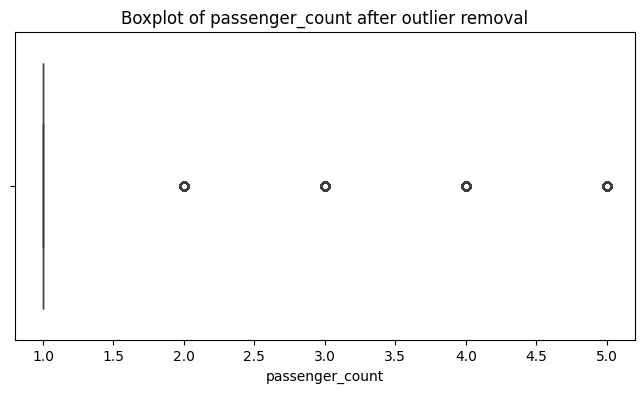

In [47]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['passenger_count'])
plt.title(f'Boxplot of passenger_count after outlier removal')
plt.show()

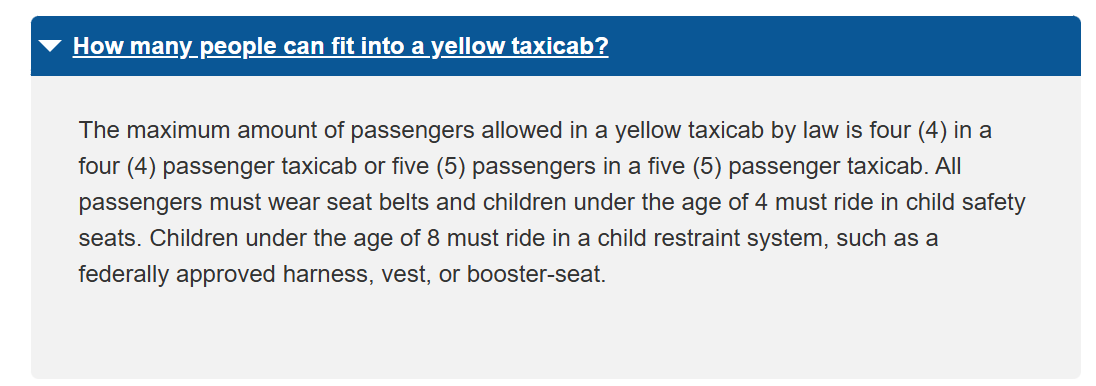


[fuente](https://www.nyc.gov/site/tlc/passengers/passenger-frequently-asked-questions.page)

## Trip distance

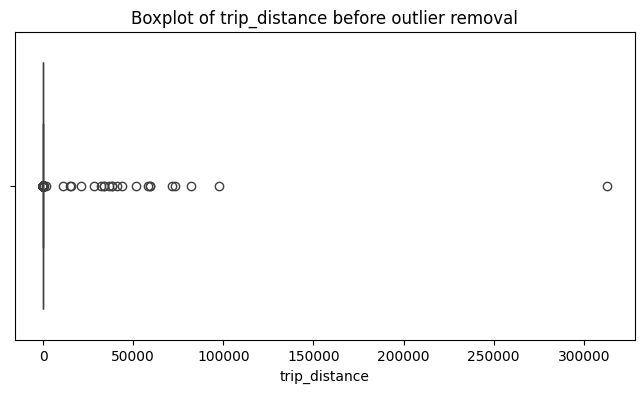

In [48]:
# boxplot de trip_distance
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['trip_distance'])
plt.title(f'Boxplot of trip_distance before outlier removal')
plt.show()

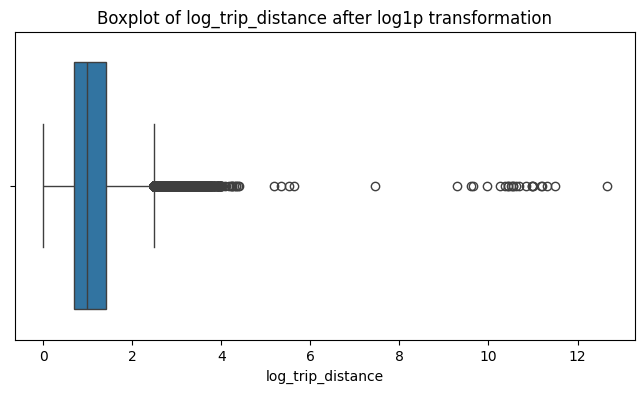

In [49]:
# Adoptamos tactica de pasar variable a logaritmica para reducir el efecto de outliers
df['log_trip_distance'] = np.log1p(df['trip_distance'])
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['log_trip_distance'])
plt.title(f'Boxplot of log_trip_distance after log1p transformation')
plt.show()

In [50]:
# sacamos outliers de log_trip_distance
q1 = df['log_trip_distance'].quantile(0.25)
q3 = df['log_trip_distance'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
df = df[(df['log_trip_distance'] >= lower_bound) & (df['log_trip_distance'] <= upper_bound)]
# agregar log_trip_distance a num_cols y metricas a iqr_ranges
num_cols.append('log_trip_distance')
iqr_ranges['log_trip_distance'] = {
    "Q1": q1,
    "Q3": q3,
    "IQR": iqr,
    "LowerBound": lower_bound,
    "UpperBound": upper_bound
}



In [51]:
# dropeamos trip_distance ya que tenemos log_trip_distance
df = df.drop(columns=['trip_distance'])

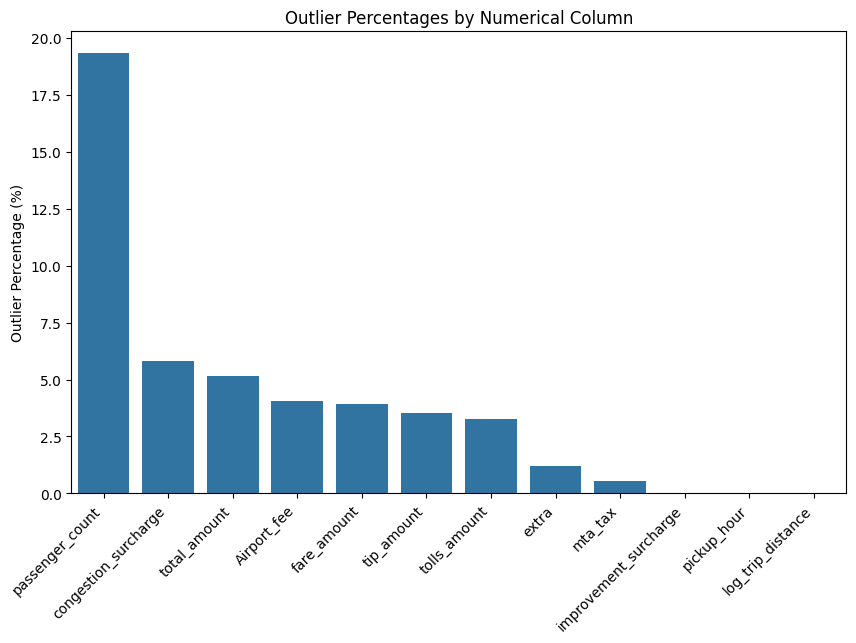

In [53]:
# grafico barras porcentajes de outliers por columna numérica
num_cols = df.select_dtypes(include=np.number).columns.tolist()
outlier_percentages = {}
for col in num_cols:
    lower = iqr_ranges[col]["LowerBound"]
    upper = iqr_ranges[col]["UpperBound"]
    
    total_count = len(df)
    outlier_count = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    
    outlier_percentage = (outlier_count / total_count) * 100
    outlier_percentages[col] = outlier_percentage
# gráfico de barras ordenado mayor a menor
outlier_percentages = dict(sorted(outlier_percentages.items(), key=lambda item: item[1], reverse=True))
plt.figure(figsize=(10, 6)) 
sns.barplot(x=list(outlier_percentages.keys()), y=list(outlier_percentages.values()))
plt.xticks(rotation=45, ha='right')
plt.ylabel('Outlier Percentage (%)')
plt.title('Outlier Percentages by Numerical Column')
plt.show()